## Imports

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sktime.utils.plotting import plot_series
from sktime.forecasting.arima import ARIMA
from sktime.split import temporal_train_test_split
from sktime.forecasting.base import ForecastingHorizon

## Load and Arrange the Data

We'll load the dataset with eaglei, noaa, era5, county-level, and engineered variables

We'll restrict to our training set (pre-2022)

For now, we'll also restrict ourselves to Maine, which has just 16 counties--a sufficient number to let us try out the techniques before deploying on the entire country

In [33]:
#Load the engineered data
df = pd.read_parquet('../Data/Merged_Data/eaglei_noaa_era5_engineered.parquet')

In [ ]:
# Restrict df to years prior to 2022
# For now, we'll just focus on Maine
df = df[df['STUSPS'] == 'ME']
df = df[df['YEAR'] < 2022]

# Use fips_code and datetime as indices
df = df.set_index(['fips_code', 'datetime'])

#Sort df
df = df.sort_index()

### Set the y-variable

We'll need to do a bit of work with the index to make it compatible with sktime.
Specifically, we'll need to recreate the multiindex and imbue it with a frequency

In [ ]:
y = df['customers_out']

#Set the multiindex on y
y = y.reset_index()

#Use fips_code and datetime as a multiindex on y
y = y.set_index(['fips_code', 'datetime'])

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
y.index = y.index.set_levels(y.index.levels[1].to_period('6h'), level=1)

## Graphing the Data

We'll start by making some plots of the data to get a sense of the sparsity of the data

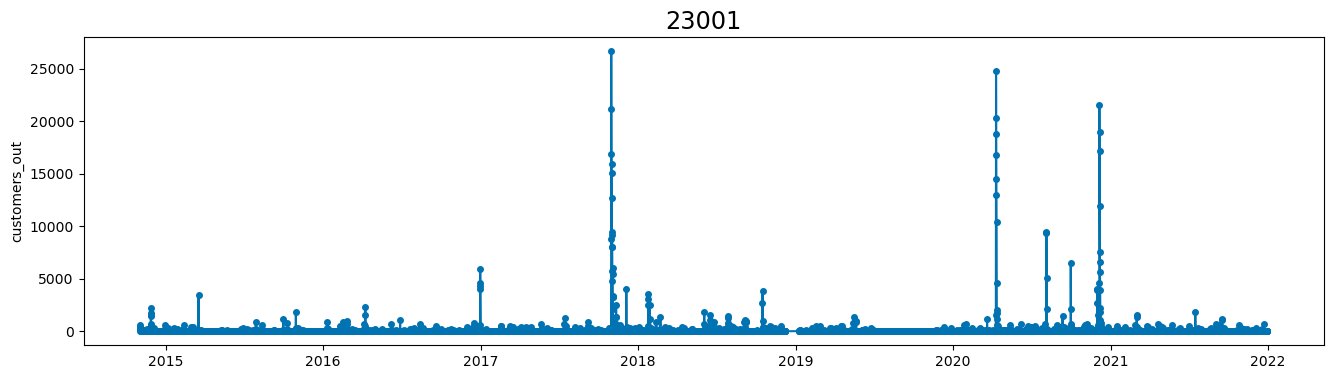

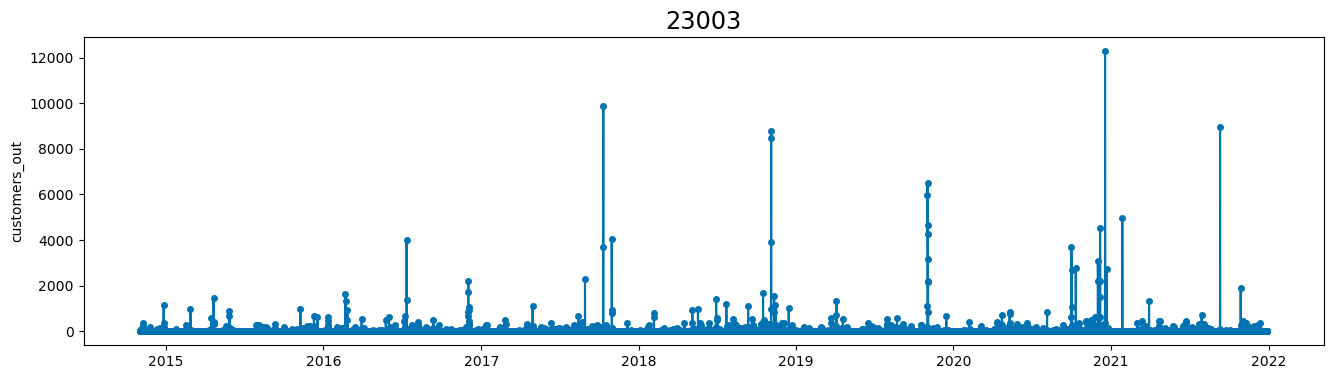

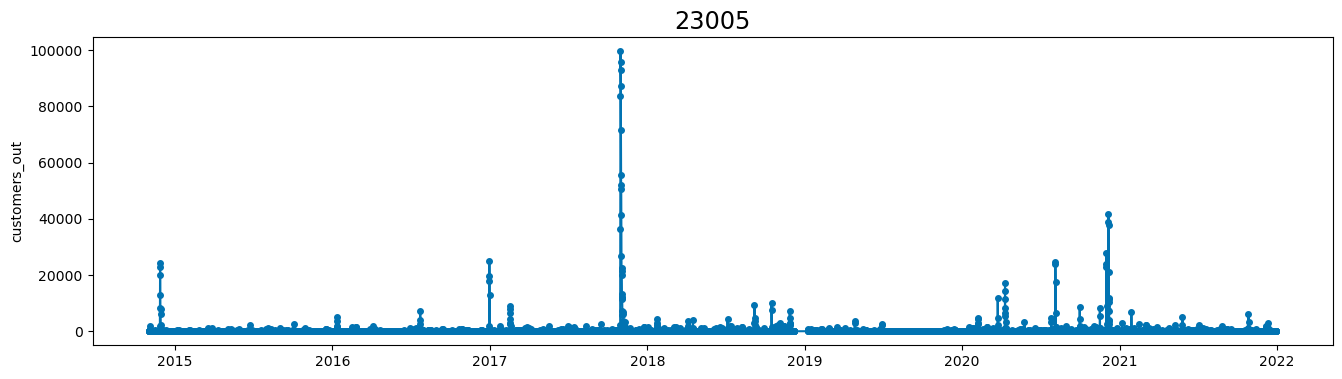

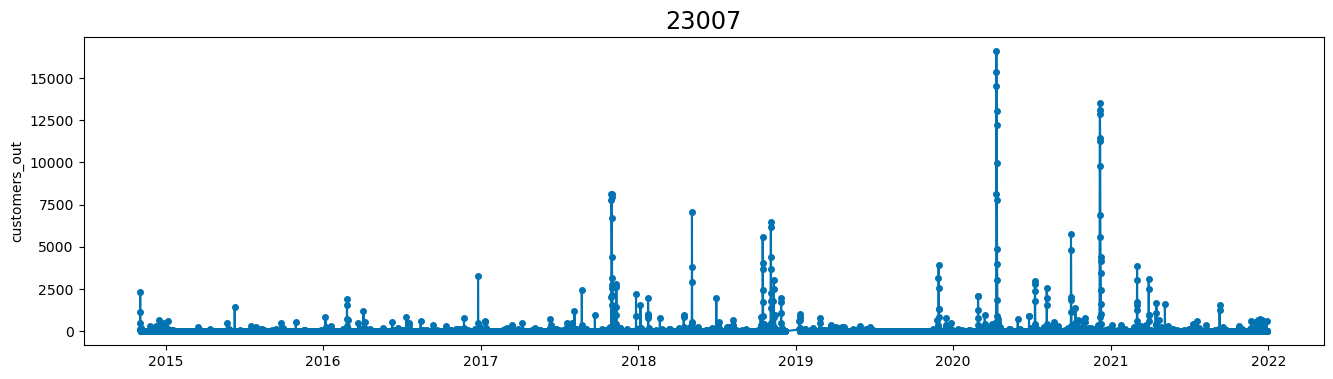

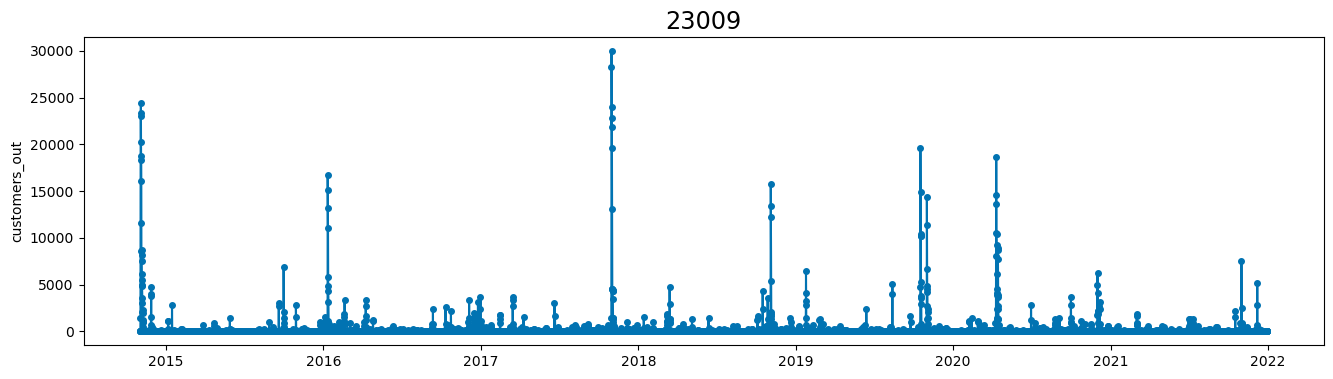

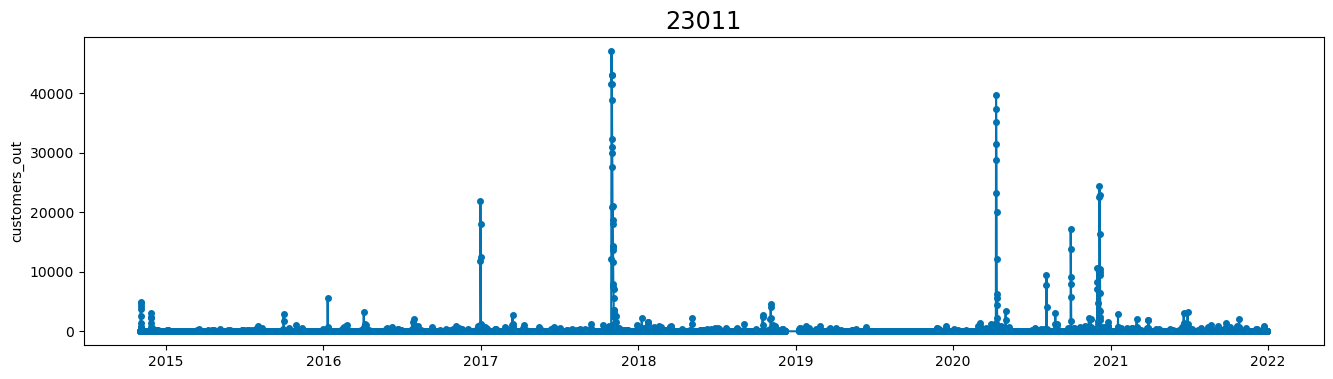

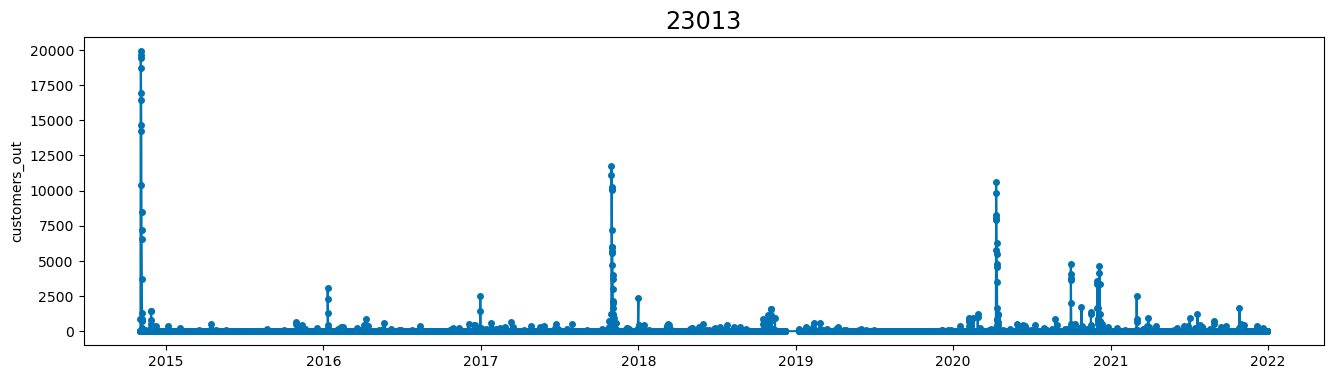

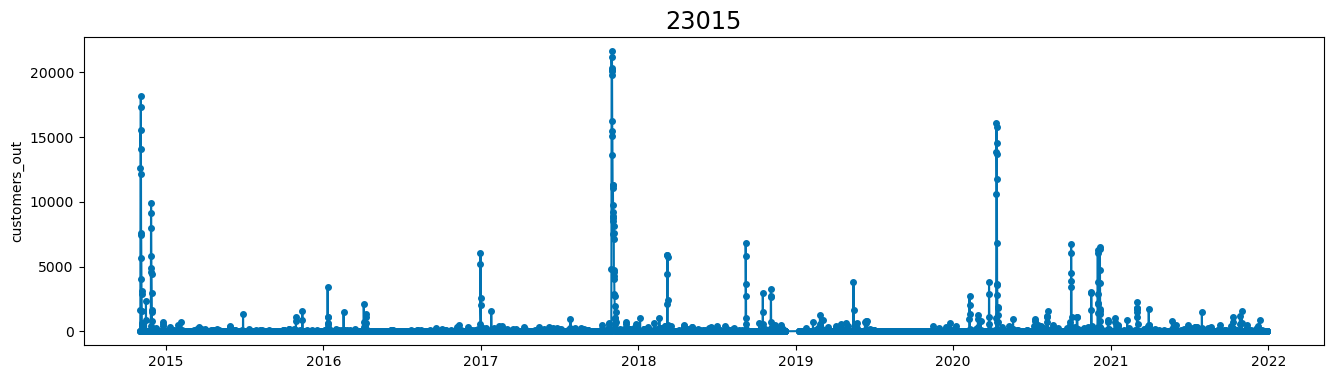

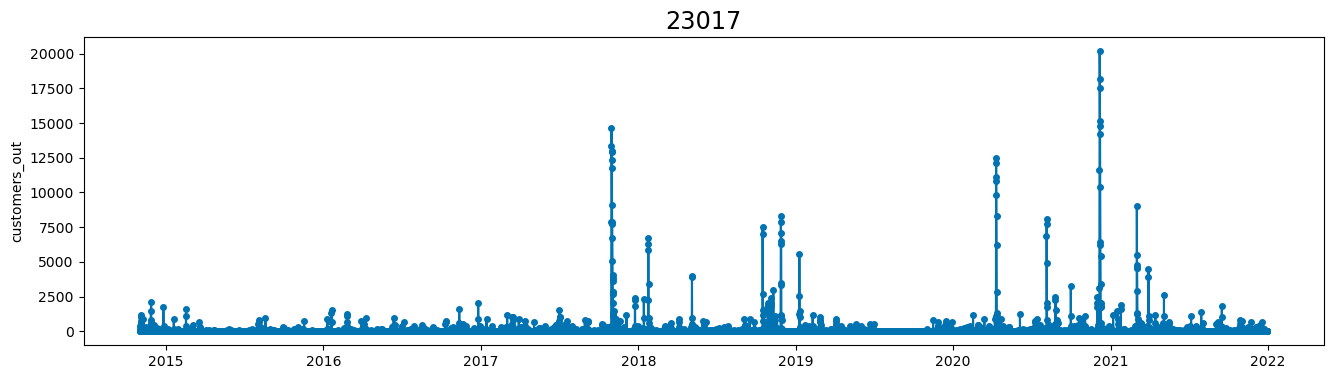

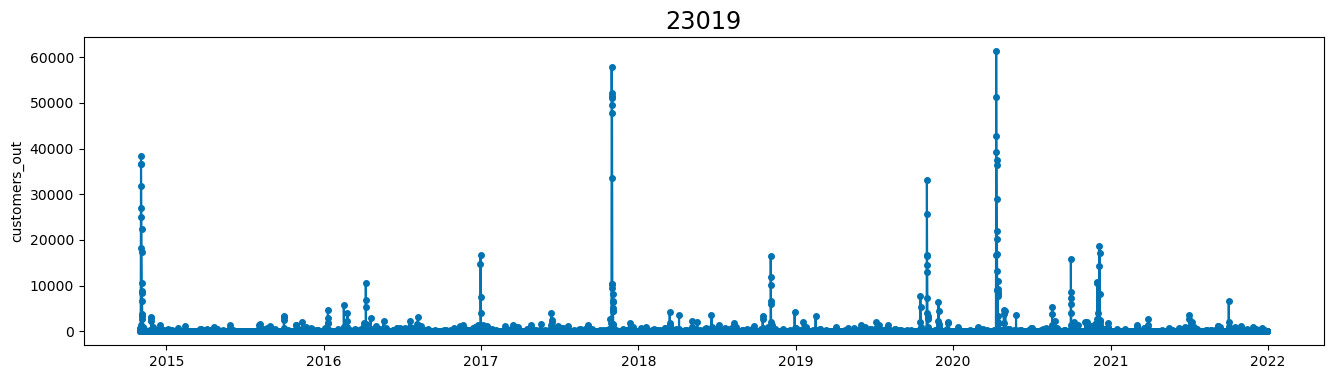

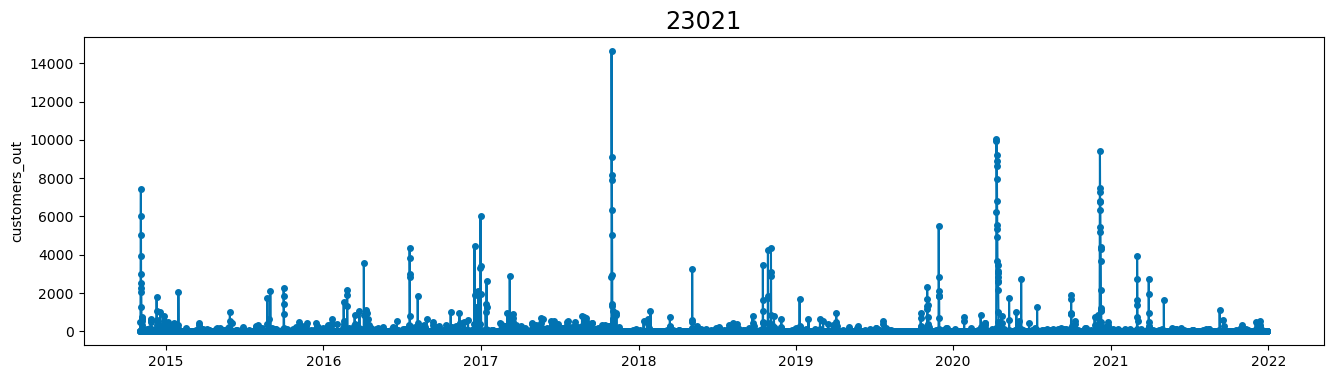

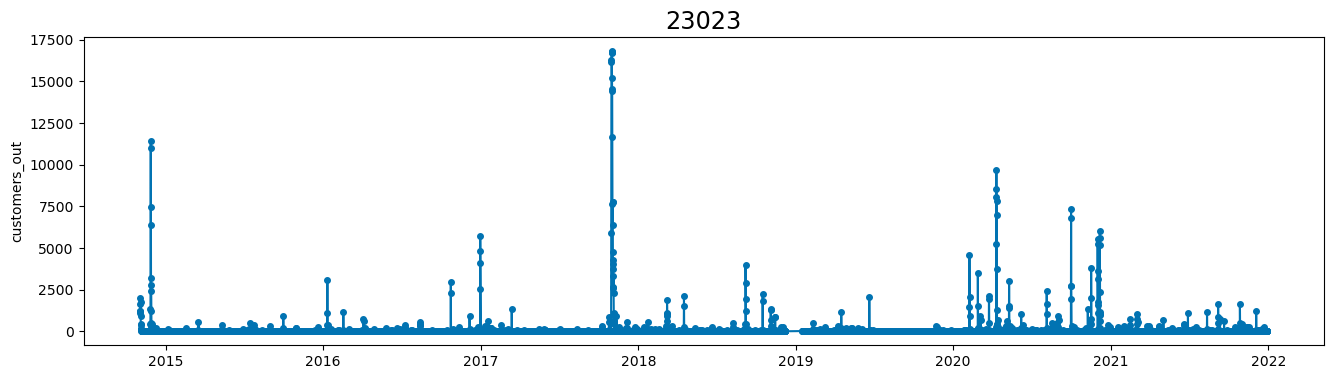

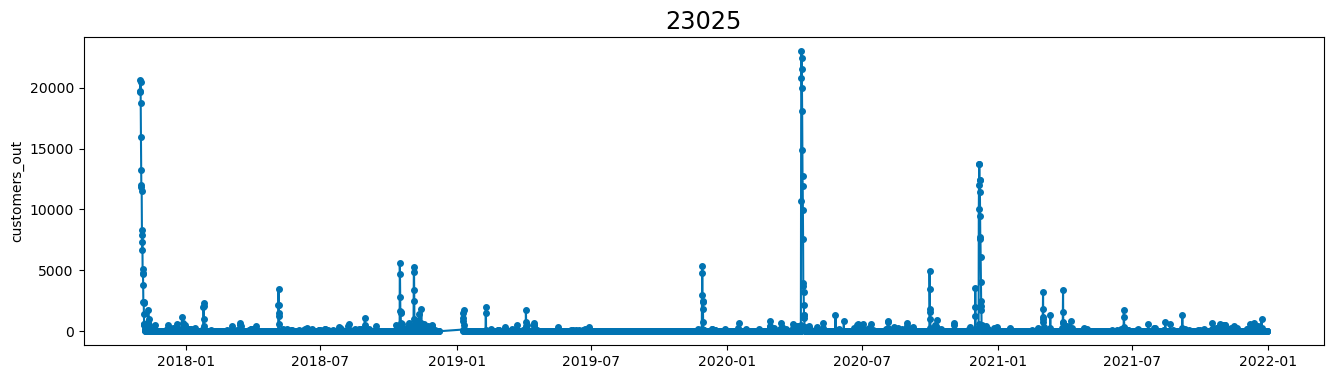

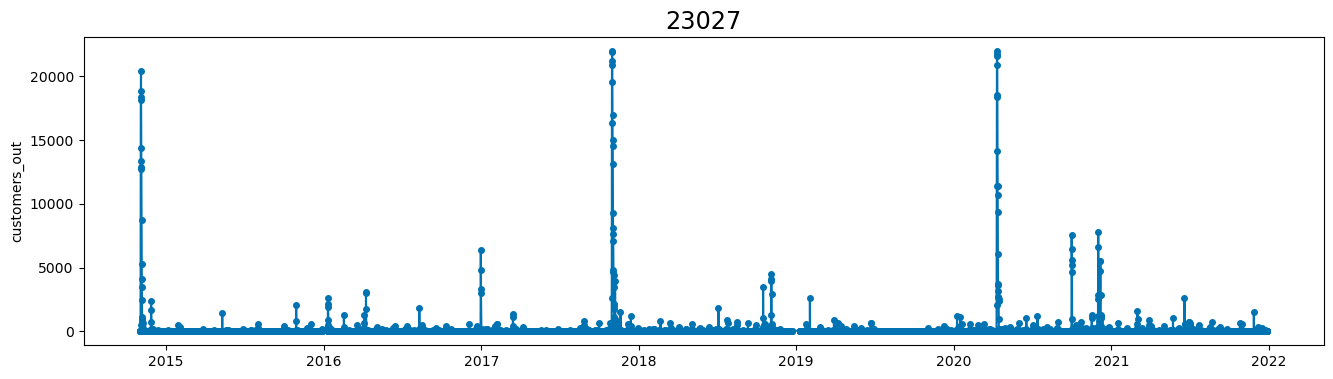

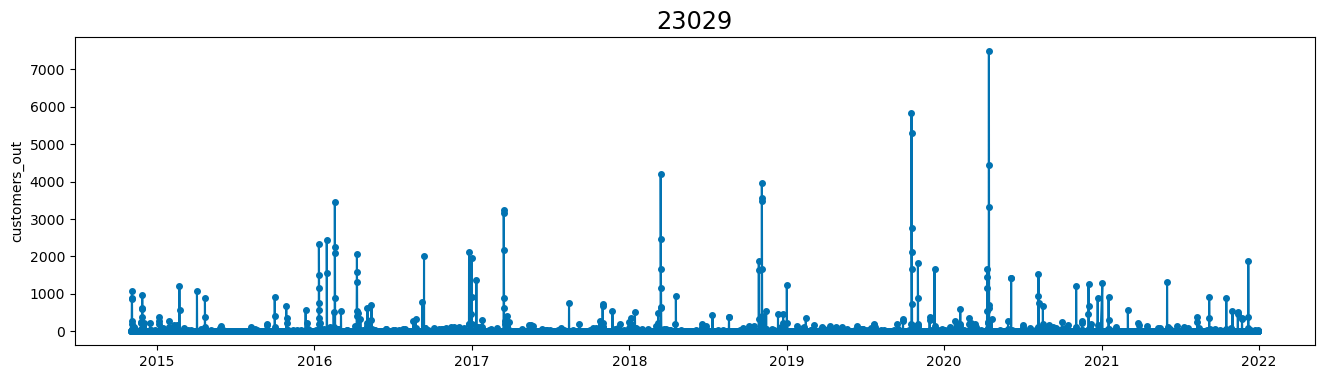

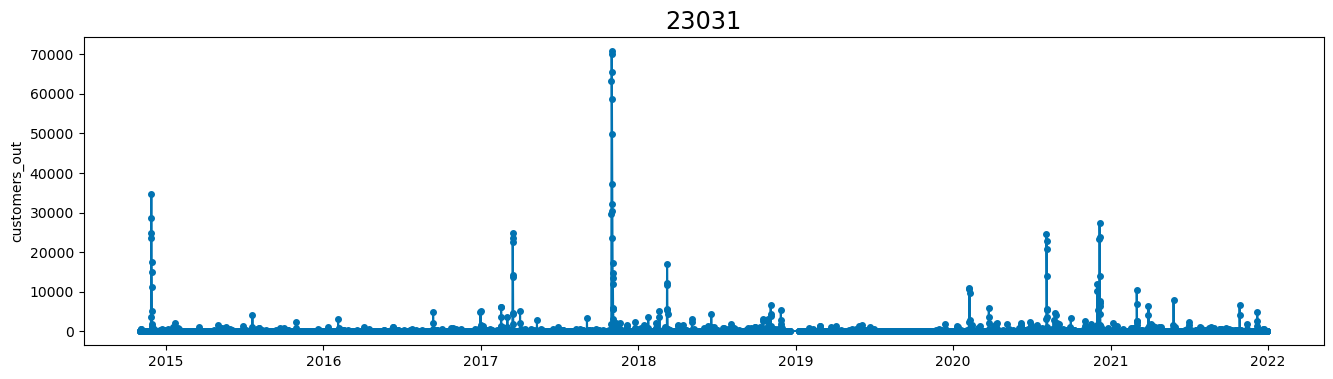

In [39]:
#For each value of fips_code, plot the value of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    plot_series(y_fips, title=fips_code)

## ACF and PACF plots

We'll make an autocorrelation and partial autocorrelation plot for each of the counties.

The ACF plots suggest that there are correlations with up to 15-20 lags, which corresponds to 4-5 days. There doesn't appear to be any consistent seasonality.

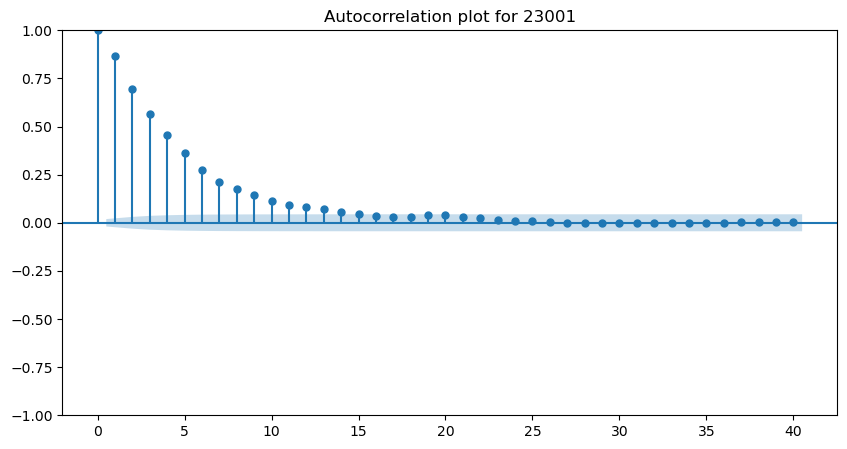

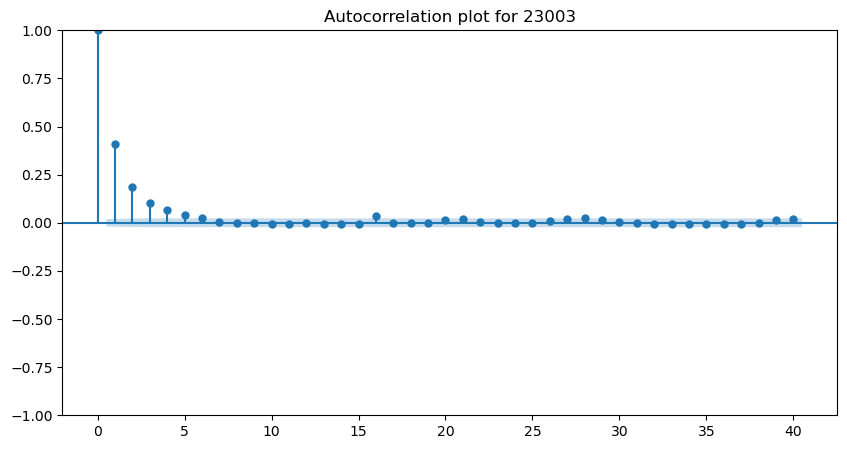

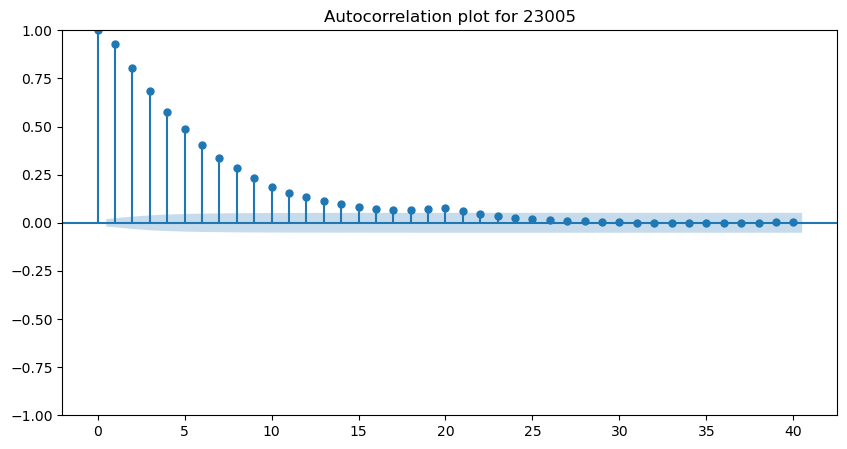

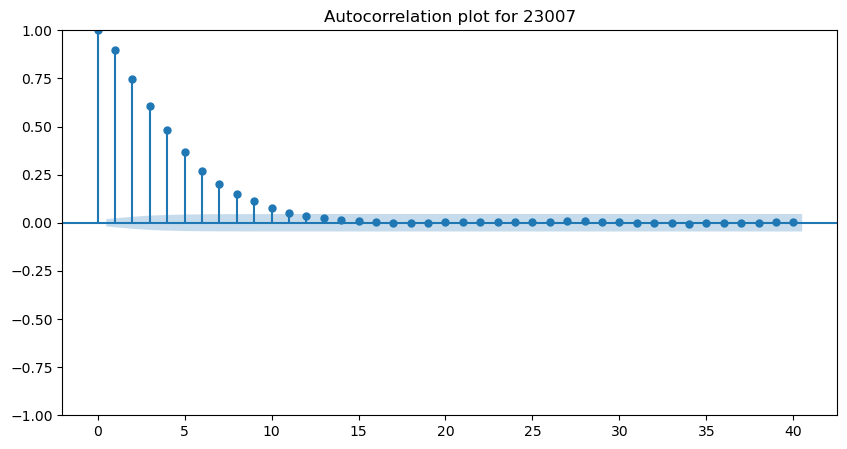

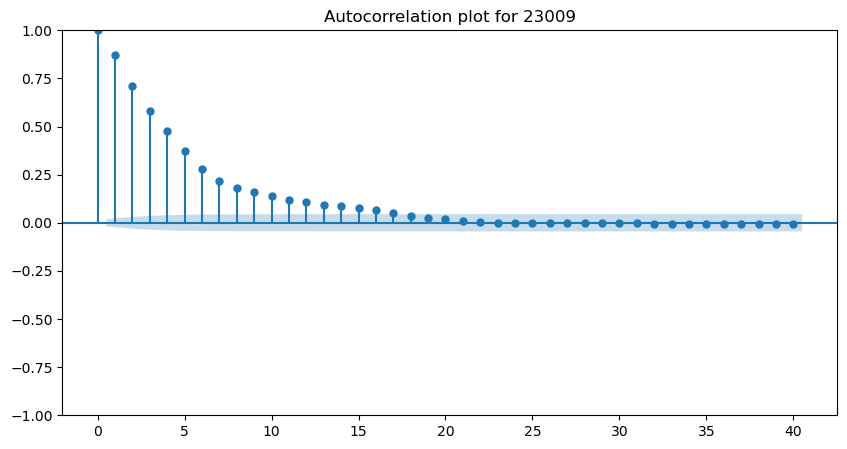

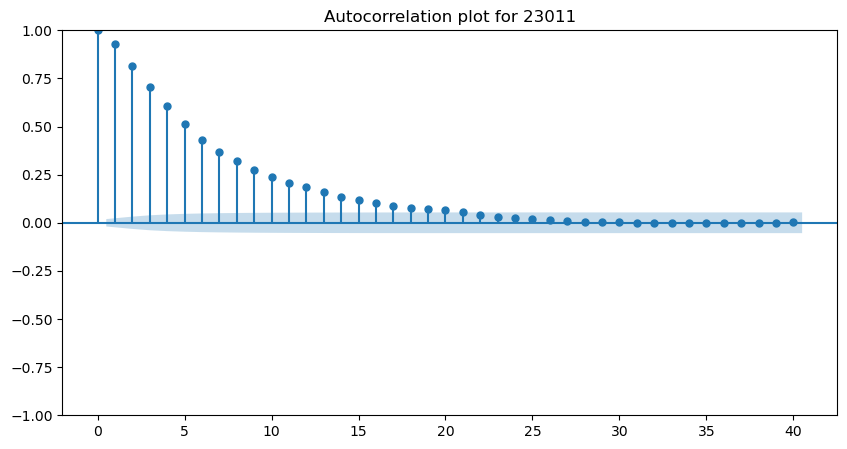

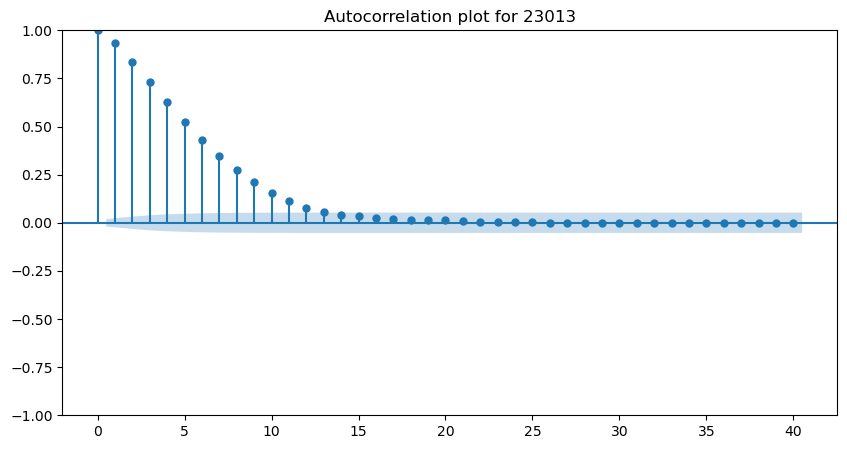

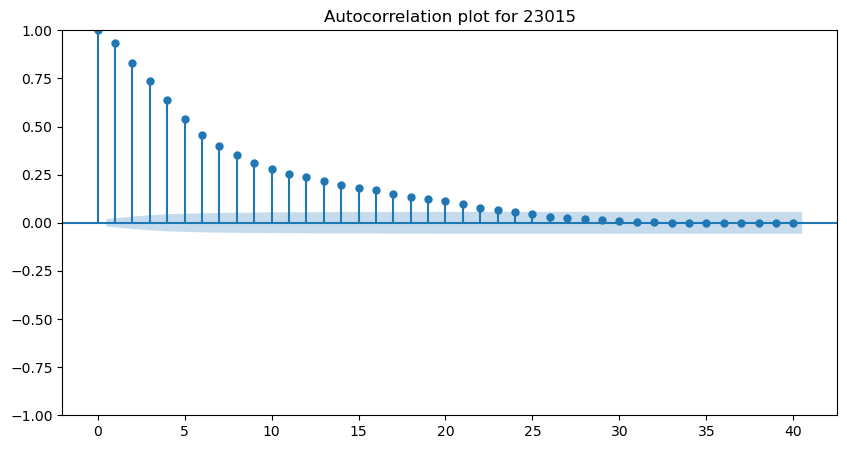

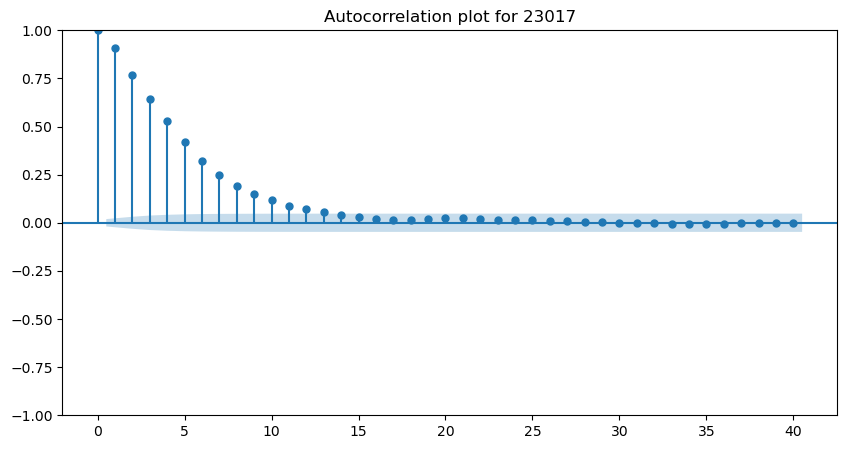

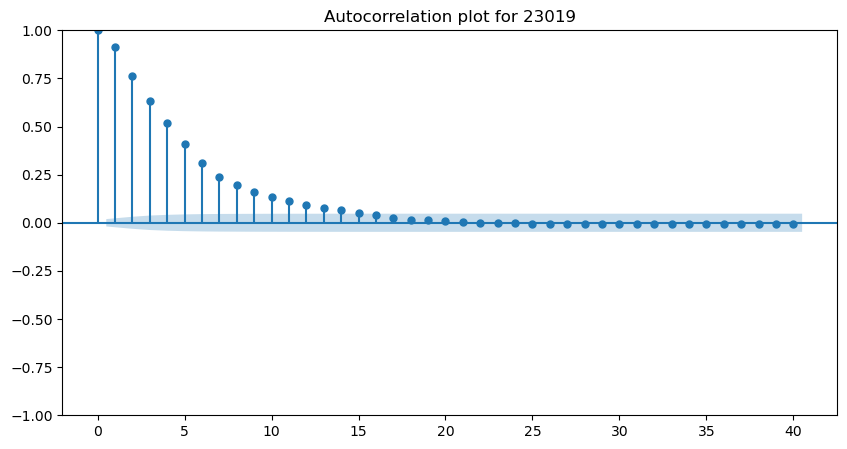

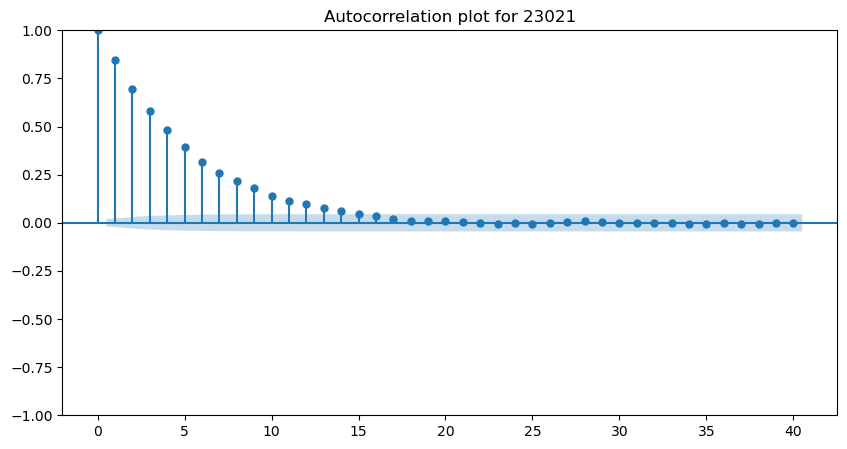

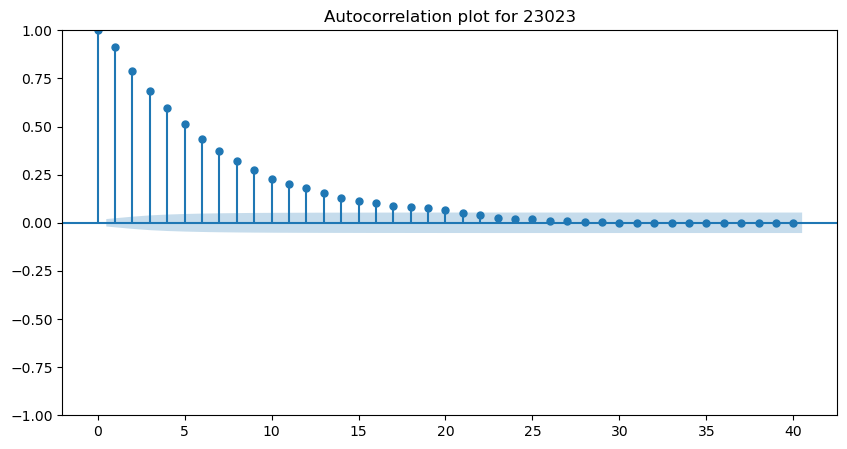

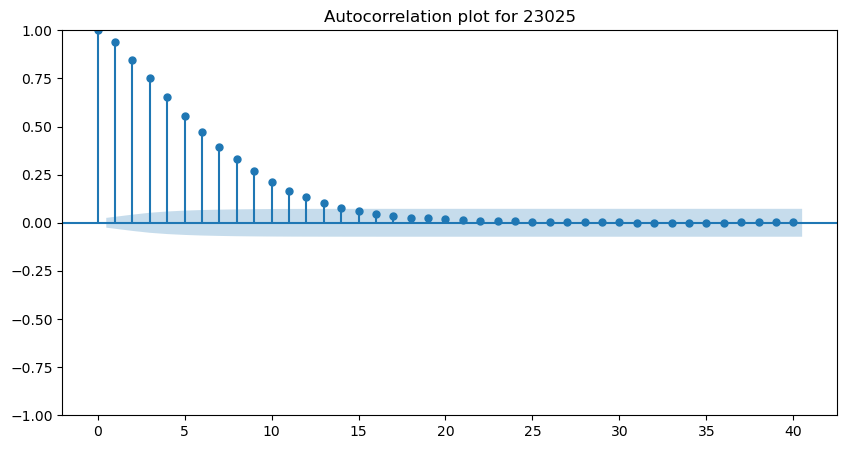

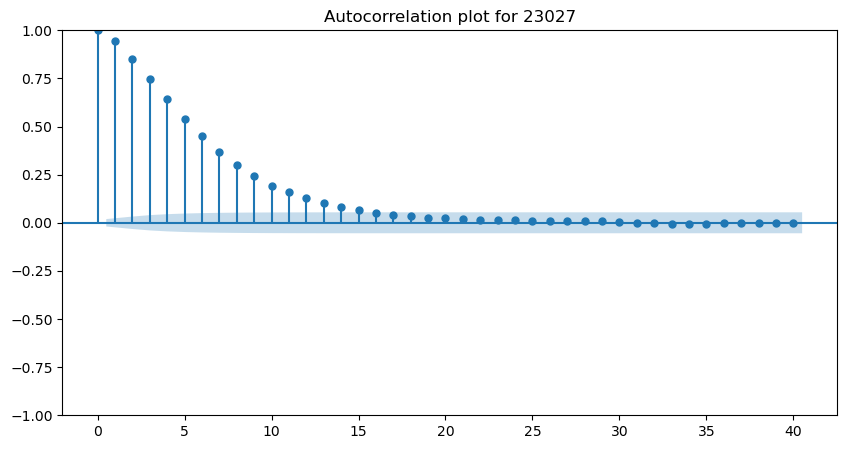

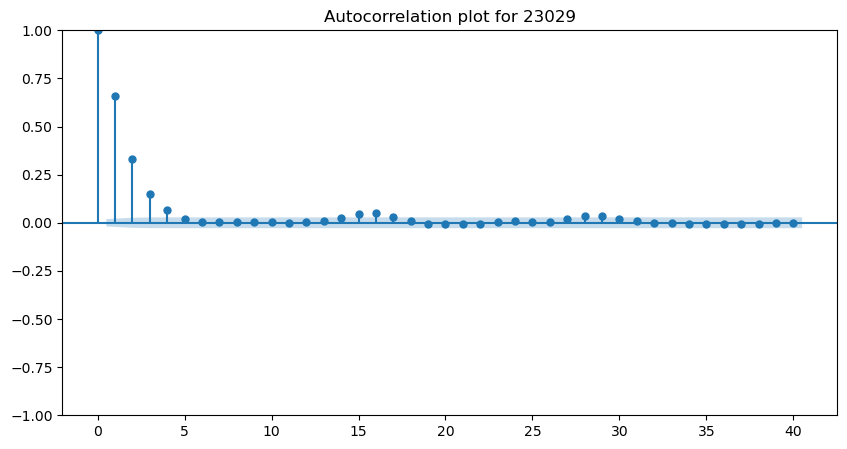

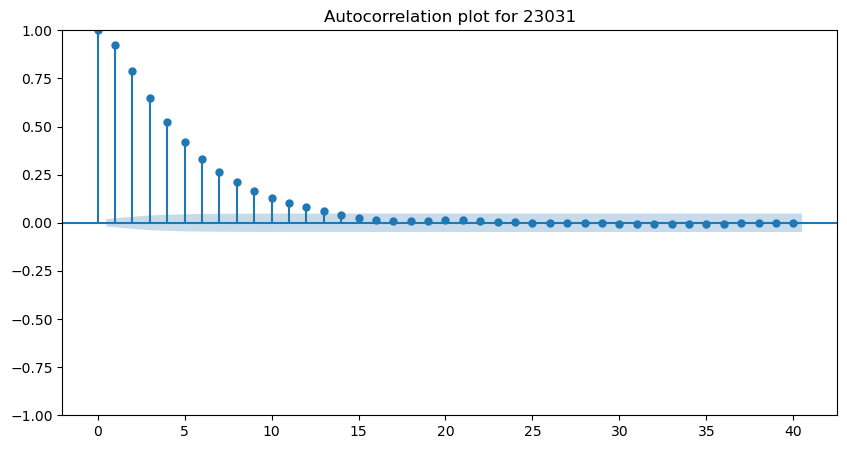

In [115]:
#For each value of fips_code use statsmodels to make an autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sm.graphics.tsa.plot_acf(y_fips['customers_out'], lags=40, ax=ax)
    plt.title(f'Autocorrelation plot for {fips_code}')
    plt.show()

### Testing for stationarity

We'll use an augmented Dickey-Fuller test. All the p-values are quite tiny, suggesting stationarity.

This suggests that an autoregressive model is appropriate.

In [ ]:
# Create a numpy array to hold the fips_codes and p-values
p_values = np.zeros((16, 2))
i=0

#For each value of fips_code, run the Augmented Dickey-Fuller test
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    result = sm.tsa.stattools.adfuller(y_fips['customers_out'])
    p_values[i,0]=int(fips_code)
    p_values[i,1]=result[1]
    i=i+1
p_values

array([[2.30010000e+04, 2.04711212e-30],
       [2.30030000e+04, 0.00000000e+00],
       [2.30050000e+04, 1.41509829e-29],
       [2.30070000e+04, 0.00000000e+00],
       [2.30090000e+04, 0.00000000e+00],
       [2.30110000e+04, 6.02021067e-30],
       [2.30130000e+04, 0.00000000e+00],
       [2.30150000e+04, 3.10024335e-29],
       [2.30170000e+04, 0.00000000e+00],
       [2.30190000e+04, 0.00000000e+00],
       [2.30210000e+04, 0.00000000e+00],
       [2.30230000e+04, 1.70417674e-29],
       [2.30250000e+04, 5.65947724e-29],
       [2.30270000e+04, 1.43020080e-28],
       [2.30290000e+04, 0.00000000e+00],
       [2.30310000e+04, 0.00000000e+00]])

### PACF Plots

There is quite a bit of variation from county to county. The first and second lags are statistically significant for all counties. It isn't uncommon for the fourth and fith lags to also be statistically significant. 

This suggests we might use a fifth-order autoregressive model.

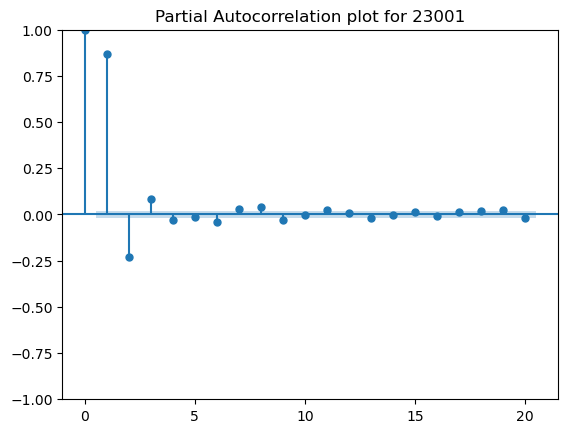

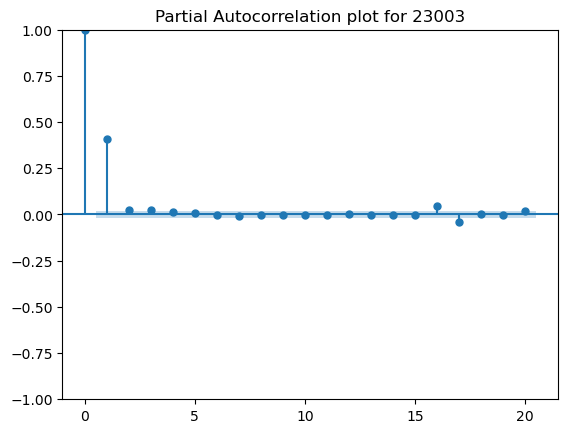

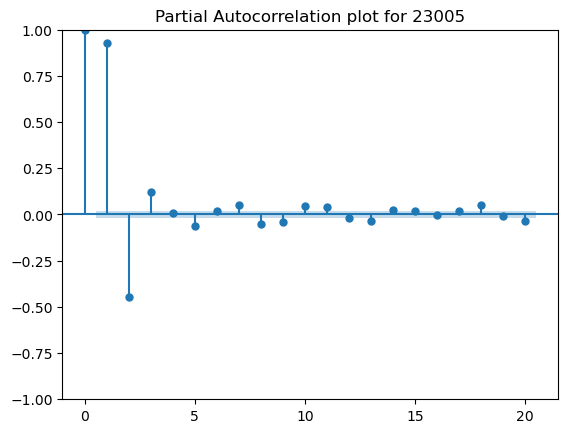

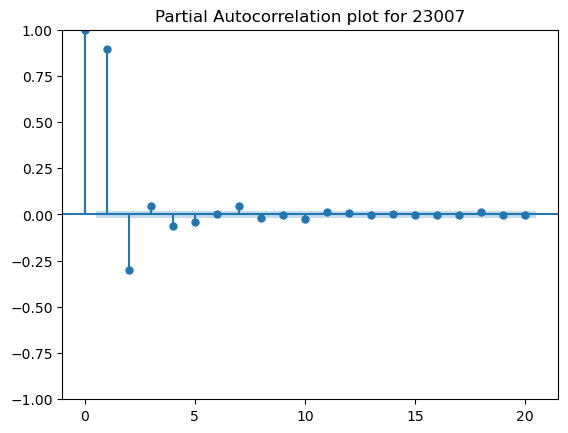

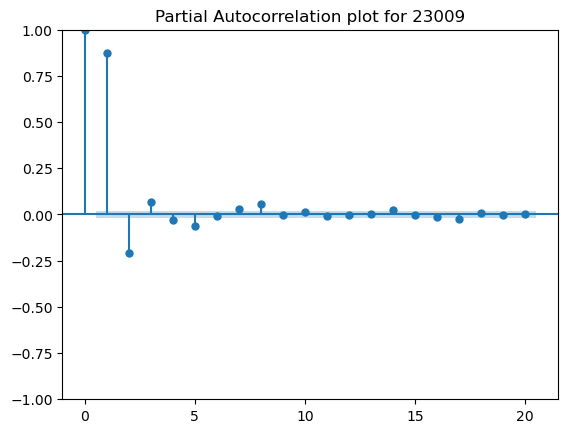

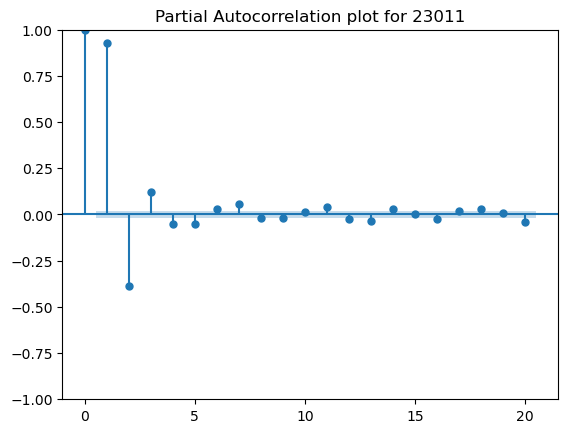

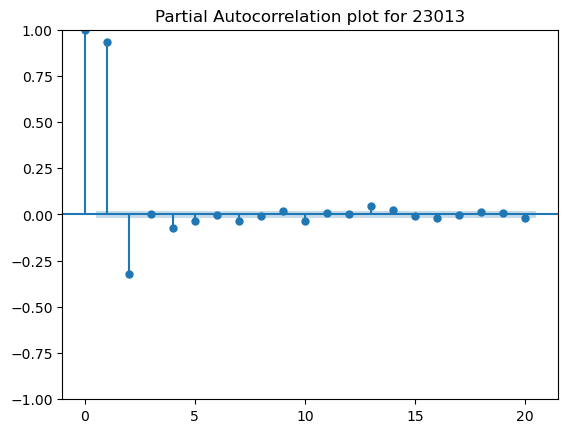

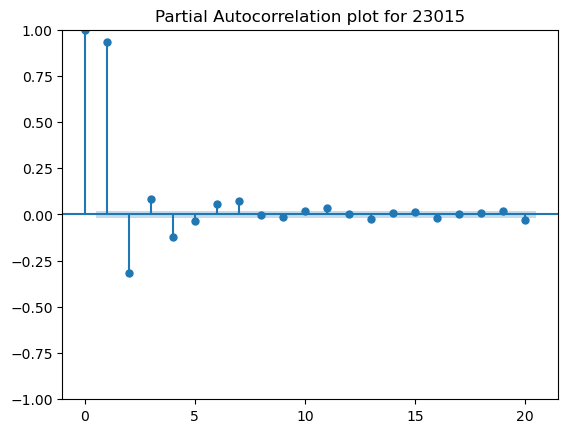

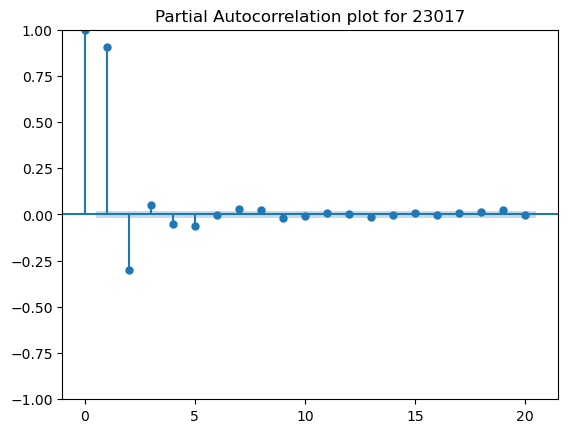

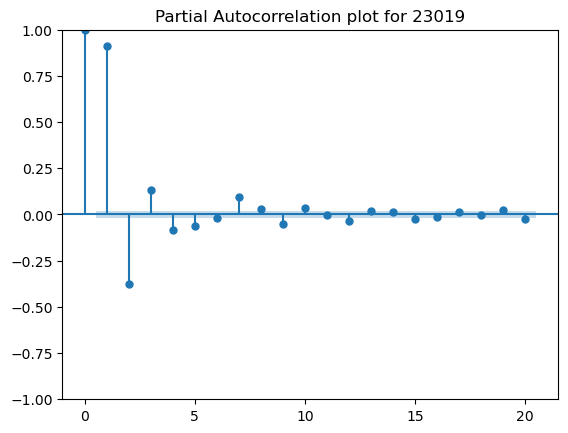

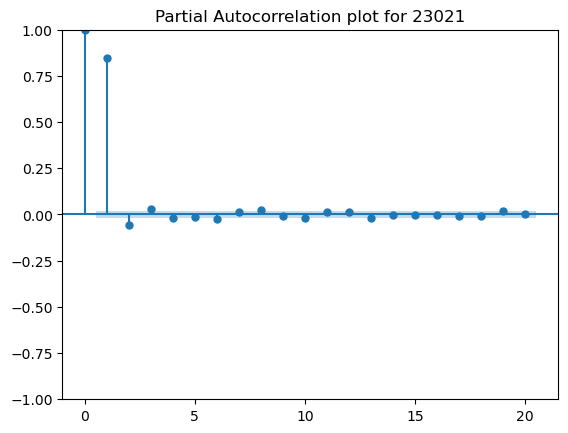

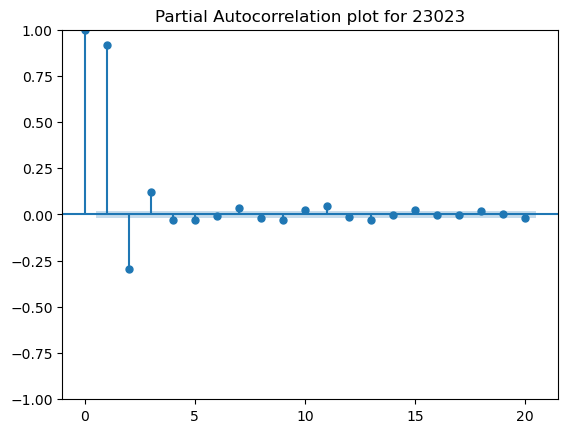

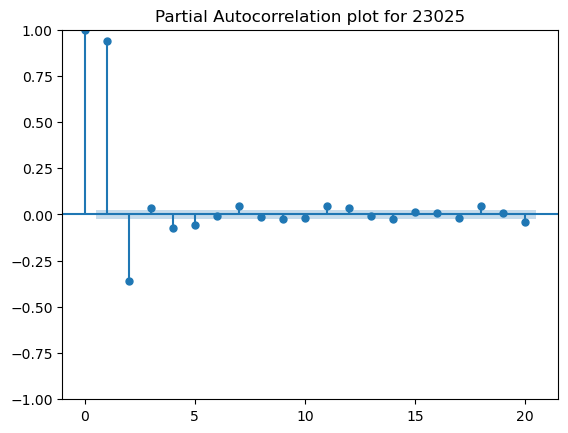

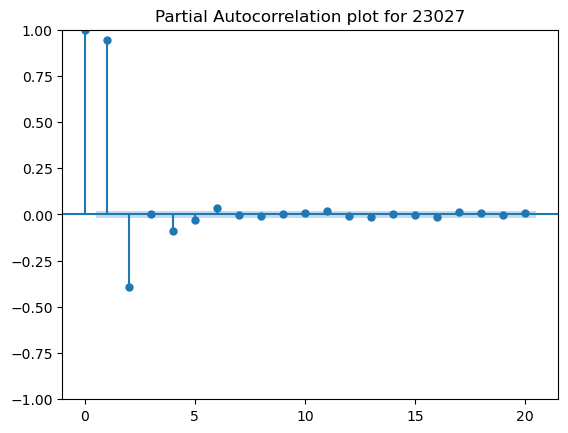

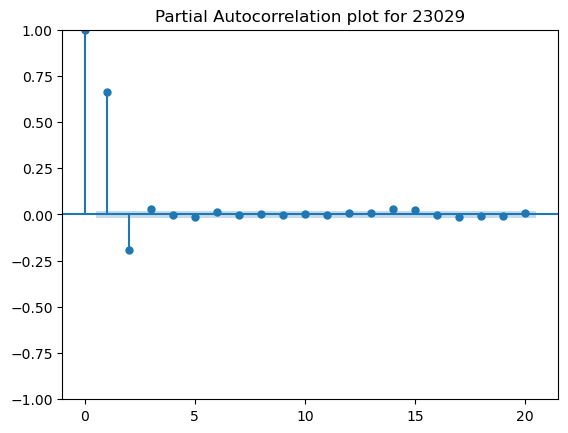

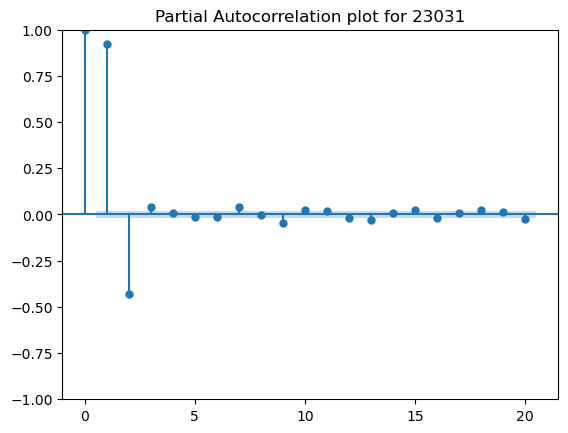

In [125]:
#For each value of fips_code make a partial autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    sm.graphics.tsa.plot_pacf(y_fips, lags=20, method='ols')
    plt.title(f'Partial Autocorrelation plot for {fips_code}')
    plt.show()

## Trying ARMIA for Prediction

We'll make a train test split to check performance of a basic ARIMA model

Following
https://github.com/sktime/sktime/blob/main/examples/01_forecasting.ipynb
 https://www.sktime.net/en/latest/examples/01c_forecasting_hierarchical_global.html


In [91]:
y_pred = forecaster.predict(forecasting_horizon)

/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/erdos_spring_2025/lib/python3.12/site-packages/

In [128]:
y_train, y_test = temporal_train_test_split(y, test_size=1460)

In [132]:
fh = ForecastingHorizon(y_test.index, is_relative=False)

# We want to make predictions over the next four 6-hour intervals
forecaster = ARIMA(order=(5, 1, 0))
forecaster.fit(y_train)

y_pred = forecaster.predict(fh)

TypeError: Invalid `fh`. The type of the passed `fh` values is not supported. Please use one of ('int', 'range', '1D np.ndarray of type int', '1D np.ndarray of type timedelta or dateoffset', 'list of type int', 'pd.RangeIndex', 'pd.PeriodIndex', 'pd.DatetimeIndex', 'pd.TimedeltaIndex'), but found type <class 'pandas.core.indexes.multi.MultiIndex'>, values = MultiIndex([(23001, '2020-12-29 06:00'),
            (23001, '2020-12-29 12:00'),
            (23001, '2020-12-29 18:00'),
            (23001, '2020-12-30 00:00'),
            (23001, '2020-12-30 06:00'),
            (23001, '2020-12-30 12:00'),
            (23001, '2020-12-30 18:00'),
            (23001, '2021-01-01 12:00'),
            (23001, '2021-01-01 18:00'),
            (23001, '2021-01-02 00:00'),
            ...
            (23031, '2021-12-28 06:00'),
            (23031, '2021-12-28 12:00'),
            (23031, '2021-12-28 18:00'),
            (23031, '2021-12-29 00:00'),
            (23031, '2021-12-29 06:00'),
         

In [96]:
# Restrict y and y_pred to year 2020 
y_2020 = y[y.index.get_level_values(1).year == 2020]
y_pred_2020 = y_pred[y_pred.index.get_level_values(1).year == 2020]

In [98]:
y_pred_2020

,,customers_out
fips_code,datetime,
